# 10장 실습 — 비동기 실행

8장에서 청킹이 예산을 늘리고 반응성을 줄였다. 9장에서 시간 앙상블이 반응성을 되찾아 주되 예산을 도로 가져갔다.

이 장은 다른 자리를 본다. **추론이 진행되는 동안 로봇은 무엇을 하고 있는가.**

8장에서 이 과제가 열린 고리 실행을 거의 못 버틴다는 것을 봤으므로, 여기서는 **명목 조건**에서 잰다. 배포 조건에서는 세 방식이 전부 바닥이라 비교 자체가 성립하지 않는다 — 그 사실도 8장의 결론과 이어지는 정보다.

세 가지 답이 있다.

- **동기** — 멈춰서 기다린다. 가장 단순하고, 1장에서 본 영차 유지가 일어나는 자리다
- **순진한 비동기** — 지난 청크를 계속 실행하다가 새 청크가 오면 갈아 끼운다. 이음매에서 명령이 튄다
- **얼리고 이어 붙이기** — 실행이 확정된 앞부분은 **얼리고**, 나머지를 그 앞부분에 이어지도록 다시 만든다. RTC 가 쓰는 방식이다

RTC 는 이 방식으로 지연 **+200 밀리초까지 성능이 변하지 않았다**고 보고하고, 동기 실행은 「지연이 커질수록 크게 무너진다」고 적는다. 이 노트북은 그 셋을 같은 과제에서 맞세운다.

실행 시간은 CPU에서 7분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (66s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 청크 정책

8·9장과 같다.

In [6]:
HMAX = 8


class Chunk(nn.Module):
    def __init__(self, h=HMAX):
        super().__init__()
        self.h = h
        self.f = nn.Sequential(nn.Linear(8, 128), nn.Tanh(),
                               nn.Linear(128, 128), nn.Tanh(),
                               nn.Linear(128, 2 * h))

    def forward(self, o):
        return self.f(o).view(-1, self.h, 2)


def collect(teacher, n=32, steps=600, seed=3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    O, A = [], []
    for _ in range(steps + HMAX):
        o = env.obs()
        ot = torch.from_numpy(o)
        with torch.no_grad():
            a = teacher.dist(ot).sample().numpy()   # 굴릴 때는 표본
            m = teacher.pi(ot).numpy()              # 배울 때는 평균
        O.append(o)
        A.append(m)
        env.step(a)
    O = np.stack(O)
    A = np.stack(A)
    X, Y = [], []
    for t in range(steps):
        X.append(O[t])
        Y.append(A[t:t + HMAX].transpose(1, 0, 2))
    return (torch.from_numpy(np.concatenate(X)),
            torch.from_numpy(np.concatenate(Y)))


def train_chunk(X, Y, epochs=120, seed=3):
    torch.manual_seed(seed)
    m = Chunk()
    opt = torch.optim.Adam(m.parameters(), 2e-3)
    n = X.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 2048):
            j = idx[k:k + 2048]
            loss = ((m(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return m


t0 = time.time()
CH = train_chunk(*collect(POLICY))
print(f"청크 정책 학습 끝  ({time.time() - t0:.0f}s)")

청크 정책 학습 끝  (7s)


## 세 가지 실행 방식을 코드로

추론이 D 스텝 걸린다고 둔다. 시각 t 에 관측을 읽고 질의를 시작하면 **새 청크는 t+D 에 도착**하고, 그 청크는 t 시점의 관측으로 만들어진 것이다.

동기 실행은 그 D 스텝 동안 지난 명령을 유지한다. 비동기 둘은 지난 청크를 계속 실행한다. 차이는 **새 청크가 도착했을 때 무엇을 하는가**이다.

- 순진한 비동기는 새 청크의 첫 칸부터 바로 쓴다. 그런데 그 첫 칸은 D 스텝 전의 상황을 위한 명령이다
- 얼리고 이어 붙이기는 새 청크에서 **이미 지나간 D 칸을 건너뛰고**, 이음매에서 지난 명령과 이어지도록 앞 몇 칸을 섞는다

두 번째가 RTC 의 「얼린다」와 「이어 붙인다」에 대응한다. RTC 는 확산 정책의 인페인팅으로 하지만, 여기서는 이음매를 부드럽게 잇는 것으로 같은 목적을 이룬다.

In [7]:
def run_async(model, mode, D, cond="명목", blend=0,
              seed=999, n=150, reps=2):
    """추론이 D 스텝 걸린다. 그 동안 로봇이 무엇을 하는가."""
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    with torch.no_grad():                 # 첫 청크는 동기로 받는다
        cur = model(torch.from_numpy(env.obs())).numpy()
    age = 0                               # 현재 청크에서 쓸 칸
    prev = cur[:, 0].copy()
    pend = None                           # (도착 시각, 청크)
    held, sc, jerk = 0, [], []
    for t in range(EP * reps):
        if pend is not None and t >= pend[0]:
            nxt = pend[1]
            if mode == "얼리고 이어 붙이기":
                # 추론하는 동안 지나간 D 칸은 건너뛴다
                age = D
                # 이음매의 불연속을 빠르게 감쇠시켜 메운다
                delta = prev - nxt[:, min(D, HMAX - 1)]
                for i in range(blend):
                    k = D + i
                    if k >= HMAX:
                        break
                    nxt[:, k] += delta * (.5 ** (i + 1))
            else:
                age = 0
            cur = nxt
            pend = None
        if pend is None:
            # 동기는 다 쓴 뒤에만 묻고, 비동기는 앞 질의가 돌아오는
            # 대로 다시 묻는다 (파이프라인을 채운다)
            ask = (age >= HMAX) if mode == "동기" else True
            if ask:
                with torch.no_grad():
                    out = model(torch.from_numpy(env.obs())).numpy()
                pend = (t + D, out)
        if age >= HMAX:
            a = prev.copy()               # 쓸 칸이 없다 — 유지한다
            held += n
        else:
            a = cur[:, age].copy()
            age += 1
        if t:
            jerk.append(np.abs(a - prev).mean())
        prev = a.copy()
        sc += env.step(a)[2]
    hold = held / (EP * reps * n)
    return np.array(sc), float(np.mean(jerk)), hold

In [8]:
t0 = time.time()
MODES = ["동기", "순진한 비동기", "얼리고 이어 붙이기"]
DS = [1, 2, 4, 6]
TAB = {}
for D in DS:
    for m in MODES:
        TAB[(D, m)] = run_async(CH, m, D)
    print(f"지연 {D}스텝 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("추론 지연", 14)
      + "".join(pad(m, 20, True) for m in MODES))
for D in DS:
    print(pad(f"{D}스텝 ({D * 50}ms)", 14)
          + "".join(pad(f"{TAB[(D, m)][0].mean():.2f}", 20, True)
                   for m in MODES))
print()
print(f"명목 조건  ·  청크 길이 {HMAX}  ·  조건마다 300판")

지연 1스텝 끝  (13s)


지연 2스텝 끝  (27s)


지연 4스텝 끝  (39s)


지연 6스텝 끝  (51s)

추론 지연                     동기       순진한 비동기  얼리고 이어 붙이기
1스텝 (50ms)                  0.09                0.49                0.01
2스텝 (100ms)                 0.05                0.14                0.26
4스텝 (200ms)                 0.00                0.03                0.00
6스텝 (300ms)                 0.01                0.00                0.00

명목 조건  ·  청크 길이 8  ·  조건마다 300판


## 동기 실행이 무너지는 이유

멈춰 있던 비율과 명령의 튐을 같이 본다.

In [9]:
print(pad("추론 지연", 12) + pad("방식", 20)
      + pad("멈춘 비율", 12, True) + pad("명령 변화", 12, True)
      + pad("성공률", 9, True))
for D in (2, 6):
    for m in MODES:
        sc, j, h = TAB[(D, m)]
        print(pad(f"{D}스텝", 12) + pad(m, 20)
              + pad(f"{h * 100:.0f}%", 12, True)
              + pad(f"{j:.3f}", 12, True)
              + pad(f"{sc.mean():.2f}", 9, True))

추론 지연   방식                   멈춘 비율   명령 변화   성공률
2스텝       동기                         20%       0.212     0.05
2스텝       순진한 비동기                 0%       0.259     0.14
2스텝       얼리고 이어 붙이기            0%       0.100     0.26
6스텝       동기                         42%       0.158     0.01
6스텝       순진한 비동기                 0%       0.306     0.00
6스텝       얼리고 이어 붙이기           65%       0.054     0.00


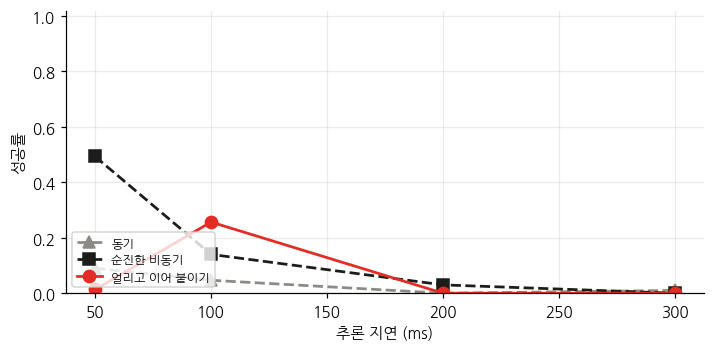

In [10]:
fig, ax = plt.subplots(figsize=(6.6, 3.3))
STY = zip(MODES, (GREY, INK, RED), ("^--", "s--", "o-"))
for m, col, mk in STY:
    ax.plot([d * 50 for d in DS],
            [TAB[(d, m)][0].mean() for d in DS], mk,
            color=col, lw=1.8, ms=8, label=m)
ax.set_xlabel("추론 지연 (ms)")
ax.set_ylabel("성공률")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## 이음매를 잇는 것이 왜 중요한가

순진한 비동기와 얼리고 이어 붙이기의 차이는 **이음매 한 군데**다. 그 한 군데가 성적을 가르는 이유는, 그 자리에서 명령이 크게 튀면 로봇이 실제로 흔들리기 때문이다.

새 청크의 첫 칸은 **D 스텝 전의 관측**으로 만들어졌다. 그 사이 로봇은 D 걸음을 갔다. 그러니 그 칸을 그대로 쓰면 이미 지나온 자리로 돌아가라는 명령이 된다. 건너뛰고 이어 붙이면 그 역행이 사라진다.

명령 변화 열이 그것을 보여 준다.

In [11]:
print(pad("추론 지연", 12)
      + "".join(pad(m, 20, True) for m in MODES[1:]))
for D in DS:
    print(pad(f"{D}스텝", 12)
          + "".join(pad(f"{TAB[(D, m)][1]:.3f}", 20, True)
                   for m in MODES[1:]))
print()
print("연속 명령의 변화 — 낮을수록 매끄럽다")

추론 지연          순진한 비동기  얼리고 이어 붙이기
1스텝                      0.220               0.112
2스텝                      0.259               0.100
4스텝                      0.409               0.159
6스텝                      0.306               0.054

연속 명령의 변화 — 낮을수록 매끄럽다


## 정리

**추론하는 동안 멈추면 안 된다.** 동기 실행은 지연이 커질수록 멈춘 비율이 늘고, 그 멈춤이 로봇의 동역학을 바꿔 학습 때와 다른 세계를 만든다.

**계속 움직이는 것만으로는 부족하다.** 순진한 비동기는 새 청크의 첫 칸을 그대로 쓰는데, 그 칸은 지연만큼 오래된 상황을 위한 명령이다. 이음매에서 명령이 튄다.

**얼리고 이어 붙이면 이음매가 사라진다.** 지나간 칸을 건너뛰고 앞 몇 칸을 이어지게 섞으면 역행이 없어진다. RTC 가 확산 정책의 인페인팅으로 하는 일을 여기서는 이음매 혼합으로 했고, 방향은 같다.

**이것이 3부의 답이다.** 8장에서 예산을 늘렸고, 9장에서 그 예산을 되돌려 주는 기법을 봤고, 10장에서 예산을 지키면서 반응성도 지키는 방법을 얻었다.

남은 것은 이 구조를 어디까지 밀 수 있는가이다. 다음 장이 **느린 층과 빠른 층을 아예 분리한다.**